# Diabetes Prediction — Logistic Regression vs. KNN

**Goal:** predict whether a patient has diabetes using the Pima Indians Diabetes dataset, and compare two classifiers — Logistic Regression and K-Nearest Neighbors — to see which one generalizes better on this data.

**Why Recall matters most here:** a missed diabetic patient (false negative) goes undiagnosed with no safety net, while a healthy patient flagged as diabetic (false positive) simply gets a cheap, low-risk follow-up A1C test. Because the cost of these two error types is so asymmetric, this project deliberately optimizes for **Recall** over Precision or Accuracy — both during hyperparameter tuning and when choosing each model's decision threshold.

**Workflow:**
1. Load & inspect the data
2. Clean impossible values (physiologically-informed imputation)
3. Exploratory Data Analysis
4. Train/Validation/Test split & scaling
5. Logistic Regression — tuning, threshold optimization, evaluation
6. KNN — tuning, threshold optimization, evaluation
7. Final comparison on the held-out test set


## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
sns.set_style('whitegrid')


In [2]:
diabetes_df = pd.read_csv(r"C:\Users\NEW USER\Downloads\archive\diabetes.csv")


### Column (Feature) Dictionary

| Column | Description |
|---|---|
| `Pregnancies` | Number of times pregnant |
| `Glucose` | Plasma glucose concentration (mg/dL) |
| `BloodPressure` | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | Triceps skinfold thickness (mm) |
| `Insulin` | 2-Hour serum insulin (mu U/ml) |
| `BMI` | Body mass index (weight in kg / (height in m)^2) |
| `DiabetesPedigreeFunction` | Diabetes likelihood based on family history |
| `Age` | Age of the patient (years) |
| `Outcome` | Target variable (0 = Non-diabetic, 1 = Diabetic) |


## 2. Initial Data Overview

In [3]:
diabetes_df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
diabetes_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Check for nulls -- note this dataset uses 0 to silently encode missing
# values in several columns, so a clean isnull() count here doesn't tell
# the full story. That's investigated next.
diabetes_df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 3. Data Quality Assessment

Several columns here can't biologically be 0 (e.g. Glucose, BloodPressure, BMI) — a 0 almost
certainly means the value wasn't recorded, not that it was actually measured as zero. Before
cleaning, confirm which columns are affected and visualize the raw distributions so the
impact of cleaning can be compared later.


In [7]:
# Identify numeric columns whose minimum is 0 -- candidates for "0 = missing"
numerical_cols = diabetes_df.select_dtypes(include=np.number)
columns_with_zero_min = numerical_cols.columns[numerical_cols.min() == 0]

print("Columns with a minimum value of 0:")
print(list(columns_with_zero_min))


Columns with a minimum value of 0:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Outcome']


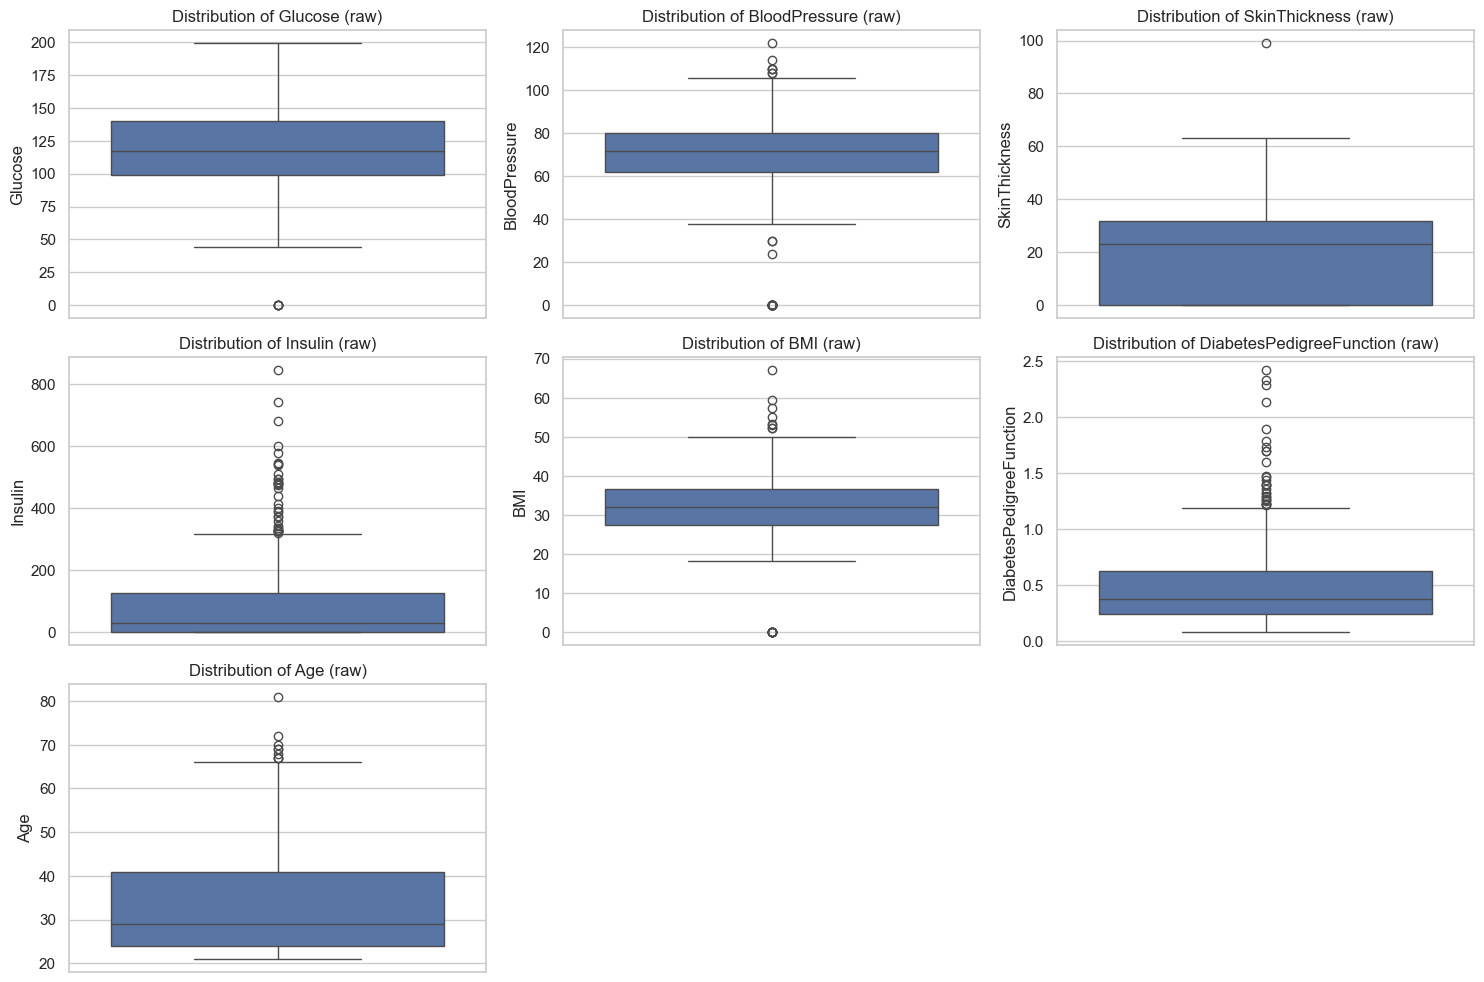

In [8]:
# Raw distributions (before cleaning) -- note the 0-value outliers in
# Glucose, BloodPressure, SkinThickness, Insulin, and BMI
feature_col = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
               'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(feature_col):
    sns.boxplot(data=diabetes_df, y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} (raw)')

for j in range(len(feature_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 4. Data Cleaning

**Strategy, column by column:**

| Column | Treatment | Reasoning |
|---|---|---|
| Glucose | 0 → NaN → median | Only 5 affected rows; median is safe |
| BloodPressure | 0 → NaN → median | Small number of affected rows |
| BMI | 0 → NaN → median | Imputed *before* SkinThickness, since SkinThickness imputation depends on BMI tiers |
| SkinThickness | Cap > 60 at 60, 0 → NaN → **bounded random imputation** (±10 of the WHO BMI-tier median) | Values > 60mm exceed the physical limit of clinical calipers. Plain median imputation was tried first but produced an artificial spike in the distribution (many rows collapsing to one identical value), so the fill was switched to a random value within ±10 of the tier median instead — this keeps the imputed values realistic while preserving natural spread. SkinThickness and BMI are grouped together because both measure adiposity (body fat), a genuine physiological relationship, not just a statistical convenience |
| Insulin | 0 → NaN → **bounded random imputation** (±30 of the Glucose-tier median) | Same spike problem as SkinThickness, same fix. Grouped by Glucose tier because insulin release is directly triggered by blood glucose level — a real causal relationship. A wider ±30 band is used here (vs. ±10 for SkinThickness) because Insulin operates on a much larger numeric scale |
| Age, Pregnancies, DiabetesPedigreeFunction, Outcome | No cleaning needed | 0 is a biologically valid value for these (and DiabetesPedigreeFunction is a computed score, not a raw measurement) |

**Ordering matters:** BMI is cleaned before SkinThickness (since SkinThickness's tiers depend on clean BMI), and Glucose is cleaned before Insulin (since Insulin's tiers depend on clean Glucose).


In [9]:
def bounded_random_impute(group, spread=10, seed=42):
    """Fill missing values in `group` with a random number drawn uniformly
    from [median - spread, median + spread]. This avoids the artificial spike
    that plain median imputation creates (many identical values), while
    keeping imputed values realistic and close to the group's center.
    """
    median = group.median()
    n_missing = group.isna().sum()
    if n_missing == 0 or pd.isna(median):
        return group
    rng = np.random.default_rng(seed)
    random_values = rng.uniform(median - spread, median + spread, size=n_missing)
    random_values = np.clip(random_values, 0, None)  # prevent negative values
    filled = group.copy()
    filled[filled.isna()] = random_values
    return filled


# Step 1: Replace impossible zeros with NaN
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_df[cols_to_fix] = diabetes_df[cols_to_fix].replace(0, np.nan)

# Step 2: Fill Glucose and BloodPressure with median (small number of missing rows)
diabetes_df['Glucose'] = diabetes_df['Glucose'].fillna(diabetes_df['Glucose'].median())
diabetes_df['BloodPressure'] = diabetes_df['BloodPressure'].fillna(diabetes_df['BloodPressure'].median())

# Step 3: Fill BMI with median -- must happen before SkinThickness, since
# SkinThickness imputation groups by BMI tier
diabetes_df['BMI'] = diabetes_df['BMI'].fillna(diabetes_df['BMI'].median())

# Step 4: Cap SkinThickness outliers (>60 -> 60), based on physical caliper limits
diabetes_df['SkinThickness'] = diabetes_df['SkinThickness'].apply(
    lambda x: 60 if pd.notna(x) and x > 60 else x
)

# Step 5: Create WHO BMI tiers (temporary column, used for SkinThickness imputation)
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
diabetes_df['BMI_Tier'] = pd.cut(diabetes_df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

# Step 6: Create Glucose tiers (temporary column, used for Insulin imputation)
glucose_bins = [0, 70, 140, 200, 300]
glucose_labels = ['Low/Fasting', 'Normal', 'Prediabetes', 'Diabetic/Severe']
diabetes_df['Glucose_Tier'] = pd.cut(diabetes_df['Glucose'], bins=glucose_bins, labels=glucose_labels, right=False)

# Step 7: Impute SkinThickness -- random value within +/-10 of the BMI-tier median
diabetes_df['SkinThickness'] = diabetes_df.groupby('BMI_Tier', observed=False)['SkinThickness'].transform(
    lambda x: bounded_random_impute(x, spread=10)
)

# Step 8: Impute Insulin -- random value within +/-30 of the Glucose-tier median
diabetes_df['Insulin'] = diabetes_df.groupby('Glucose_Tier', observed=False)['Insulin'].transform(
    lambda x: bounded_random_impute(x, spread=30)
)

# Step 9: Drop temporary tier columns -- restore the dataframe to its original structure
diabetes_df = diabetes_df.drop(columns=['BMI_Tier', 'Glucose_Tier'])

# Step 10: Sanity check -- should show 0 remaining NaNs anywhere
print(diabetes_df.isna().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
# Post-cleaning summary statistics -- compare against the raw describe()
# above to confirm the impossible zeros are gone and the ranges look sensible
diabetes_df.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.000000,3.000000,6.000000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.750000,117.000000,140.250000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.000000,72.000000,80.000000,122.00
SkinThickness,768.0,28.490807,9.552865,7.000,22.000000,28.363227,35.000000,60.00
Insulin,768.0,140.428184,91.428865,14.000,87.691761,115.991469,175.445792,846.00
BMI,768.0,32.455208,6.875177,18.200,27.500000,32.300000,36.600000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.243750,0.372500,0.626250,2.42
Age,768.0,33.240885,11.760232,21.000,24.000000,29.000000,41.000000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.000000,0.000000,1.000000,1.00


## 5. Exploratory Data Analysis

### 5.1 Univariate Distributions (post-cleaning)

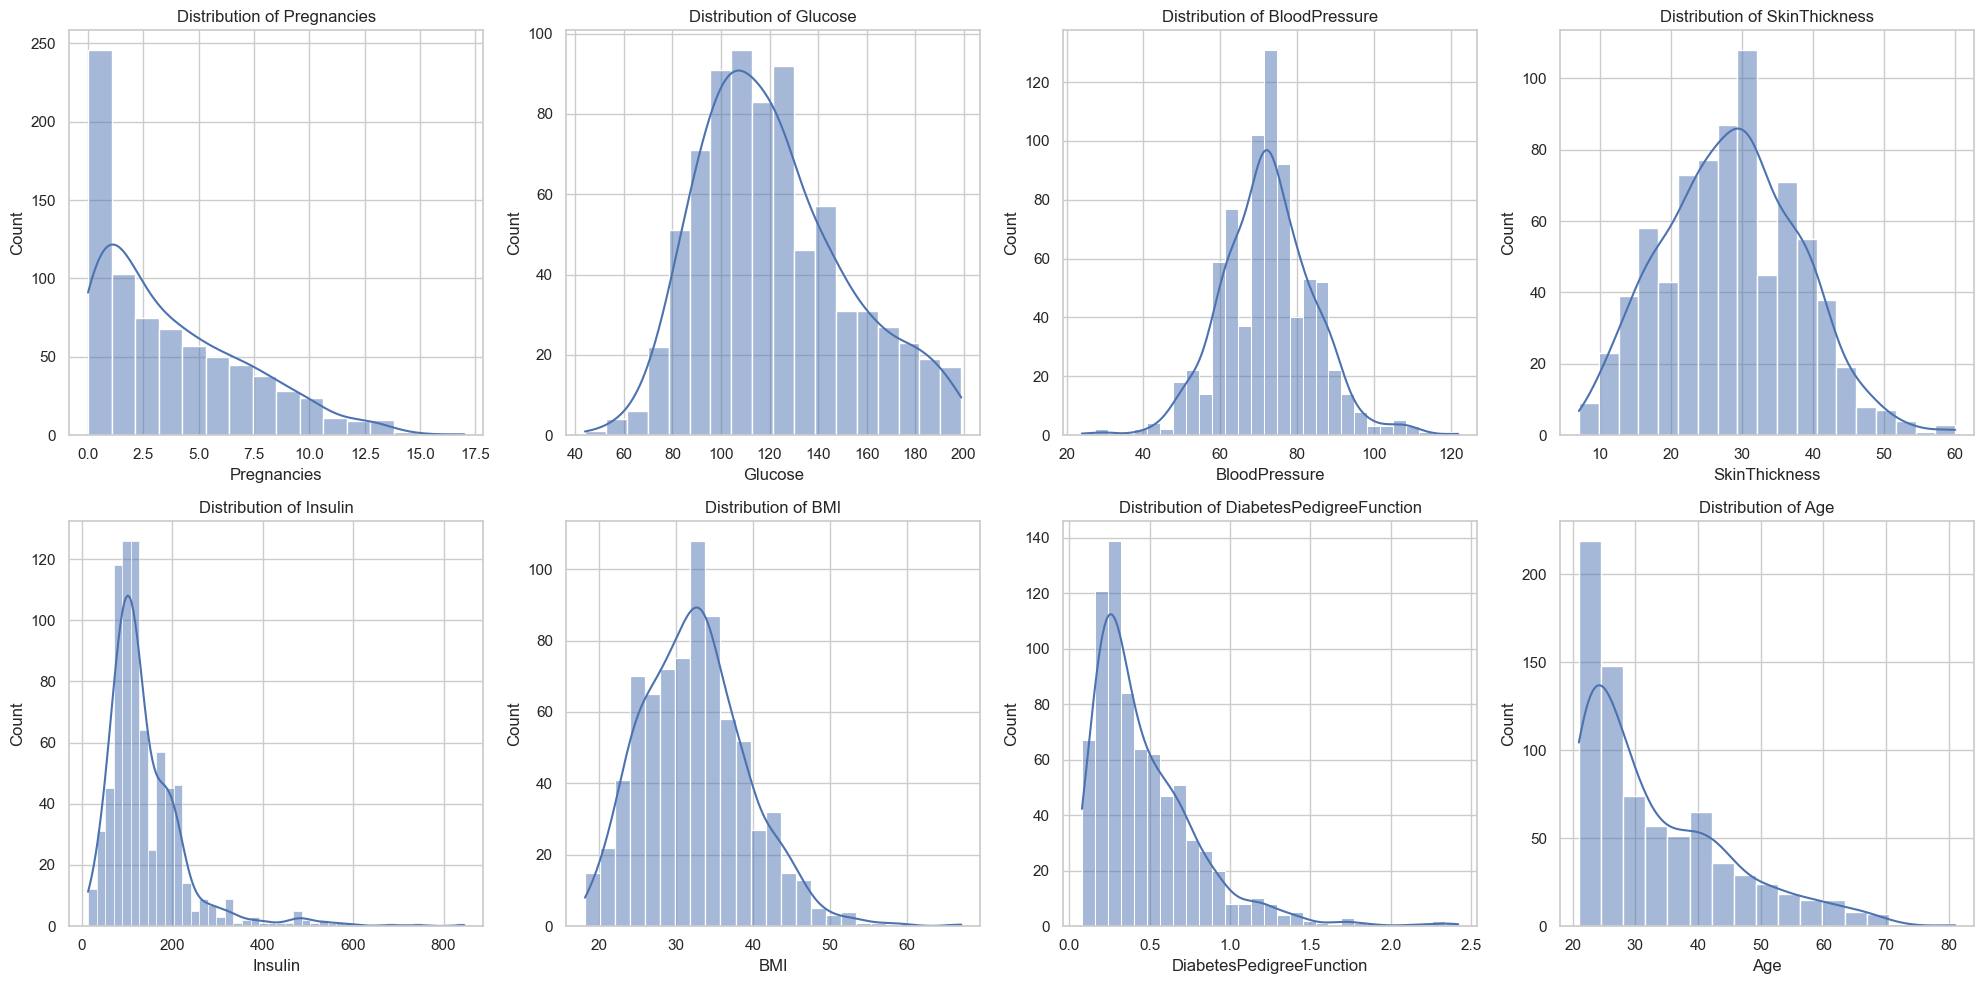

In [11]:
feature_col = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
               'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_col):
    sns.histplot(data=diabetes_df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

for j in range(len(feature_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 5.2 Class Balance

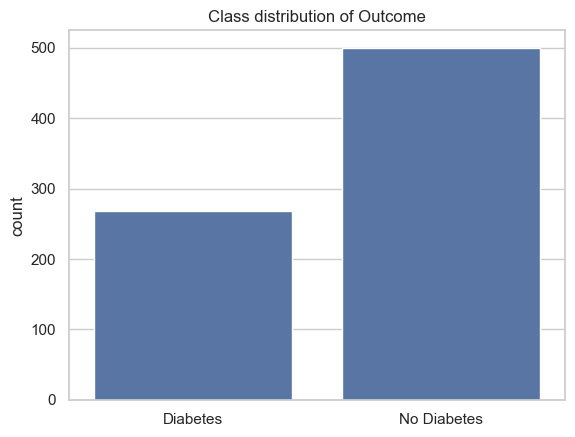

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [12]:
sns.countplot(x=diabetes_df['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'}))
plt.title('Class distribution of Outcome')
plt.xlabel('')
plt.show()

print(diabetes_df['Outcome'].value_counts())
print(diabetes_df['Outcome'].value_counts(normalize=True) * 100)


The dataset is moderately imbalanced (roughly 65% Non-Diabetic / 35% Diabetic). This is
mild enough that heavy rebalancing (e.g. SMOTE) isn't necessary, but it does mean **accuracy
alone would be a misleading metric** -- a model that always predicts "No Diabetes" would still
score ~65% accuracy while catching zero real cases. Recall, Precision, F1, and the confusion
matrix are used throughout instead.


### 5.3 Bivariate Analysis (feature distributions split by Outcome)

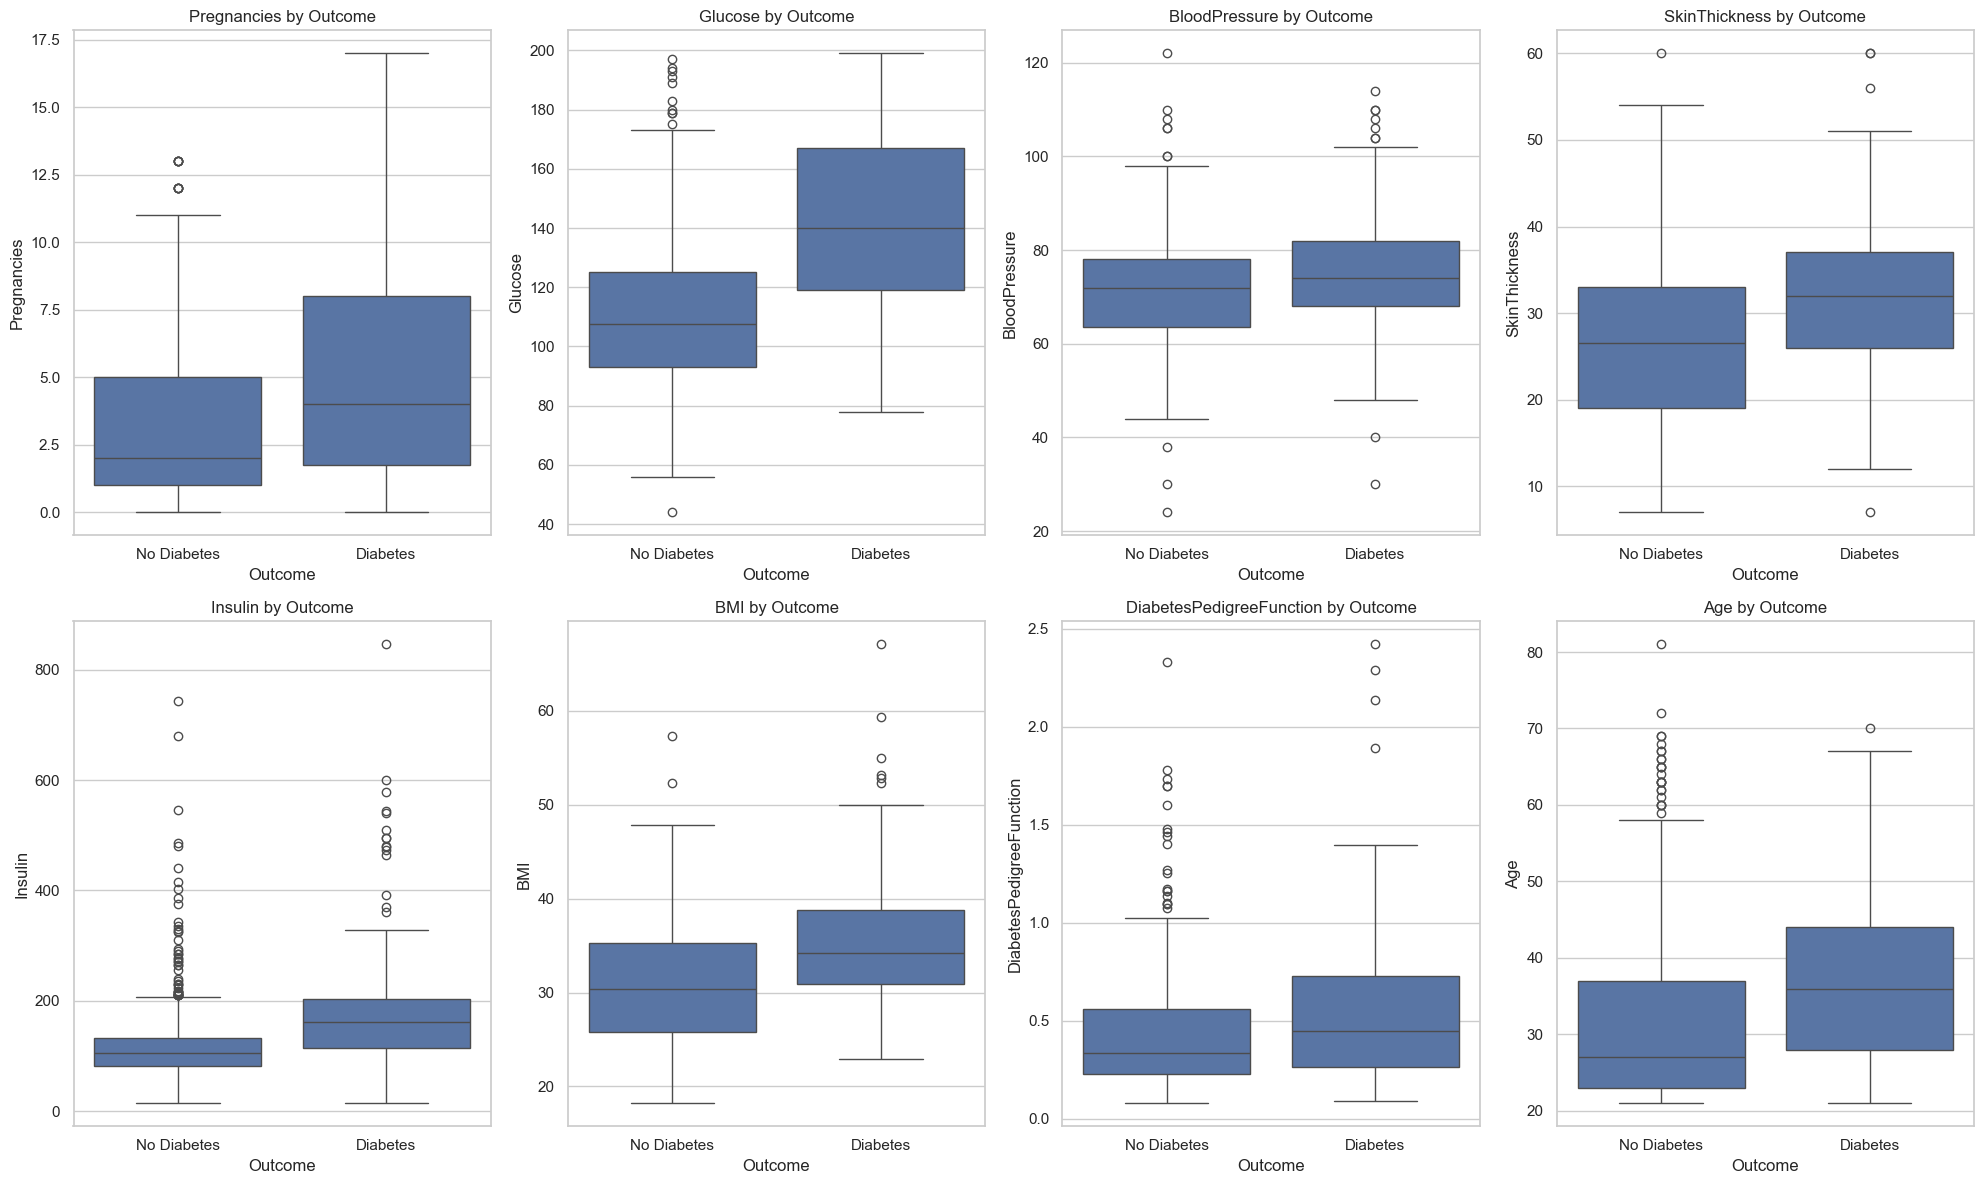

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(feature_col):
    sns.boxplot(data=diabetes_df, x='Outcome', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Outcome')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'])

for j in range(len(feature_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### EDA Findings — Bivariate Analysis (Outcome split)

**Strong separation between classes:**
- Glucose — clearest predictor; diabetic group's median sits well above the non-diabetic group
- Pregnancies — diabetic group has a higher median and wider spread
- BMI — diabetic group's median is visibly higher
- Age — diabetic group skews older

**Moderate separation:**
- Insulin, SkinThickness — some upward shift for the diabetic group, but substantial overlap

**Weak separation:**
- BloodPressure — nearly identical distributions across both classes
- DiabetesPedigreeFunction — mostly overlapping, with some higher outliers in the diabetic group


### 5.4 Correlation Heatmap

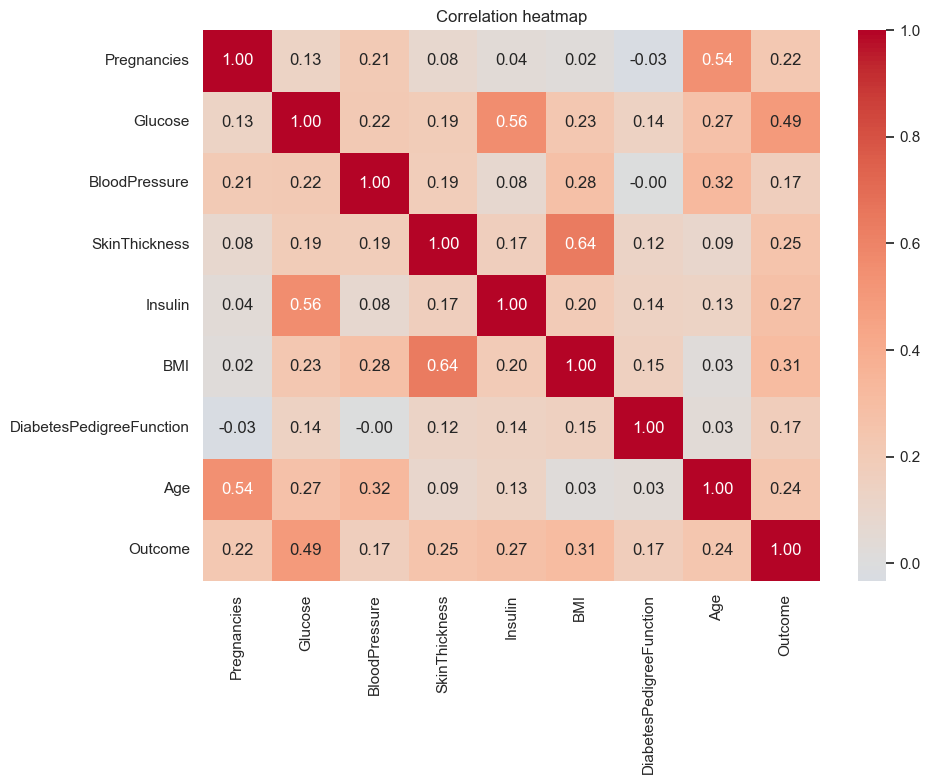

In [14]:
plt.figure(figsize=(10, 8))
corr = diabetes_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()


**Correlation with Outcome (ranked):** Glucose (0.49) > BMI (0.31) > Insulin (0.27) >
SkinThickness (0.25) > Age (0.24) > Pregnancies (0.22) > BloodPressure / DiabetesPedigreeFunction (0.17).

**Notable feature-feature correlations:**
- SkinThickness ↔ BMI: 0.64 (both measure body adiposity)
- Glucose ↔ Insulin: 0.56 (insulin release is directly triggered by glucose level)
- Age ↔ Pregnancies: 0.54 (pregnancies naturally accumulate with age)

These correlations reflect genuine physiological relationships rather than redundant or
poorly-designed features -- worth keeping in mind for the multicollinearity check below.


### 5.5 Multicollinearity Check (VIF)

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# add_constant is required -- without it, VIF values come out artificially
# inflated (a well-known gotcha of statsmodels' VIF function)
X_vif = add_constant(diabetes_df[feature_cols])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const']
print(vif_data.sort_values('VIF', ascending=False))


                    Feature       VIF
6                       BMI  1.852089
4             SkinThickness  1.711357
2                   Glucose  1.612677
8                       Age  1.607577
5                   Insulin  1.496692
1               Pregnancies  1.434663
3             BloodPressure  1.243997
7  DiabetesPedigreeFunction  1.048890


All VIF values come out between 1.05 and 1.85 -- well below even the conservative
threshold of 5. Despite the moderate pairwise correlations seen in the heatmap
(SkinThickness/BMI at 0.64, Glucose/Insulin at 0.56), there is **no problematic
multicollinearity** once all features are considered together. No features were dropped;
L2 regularization in the Logistic Regression model (tuned via `C` below) further helps
stabilize coefficients for the moderately correlated pairs.


### 5.6 Pairplot (top predictors)

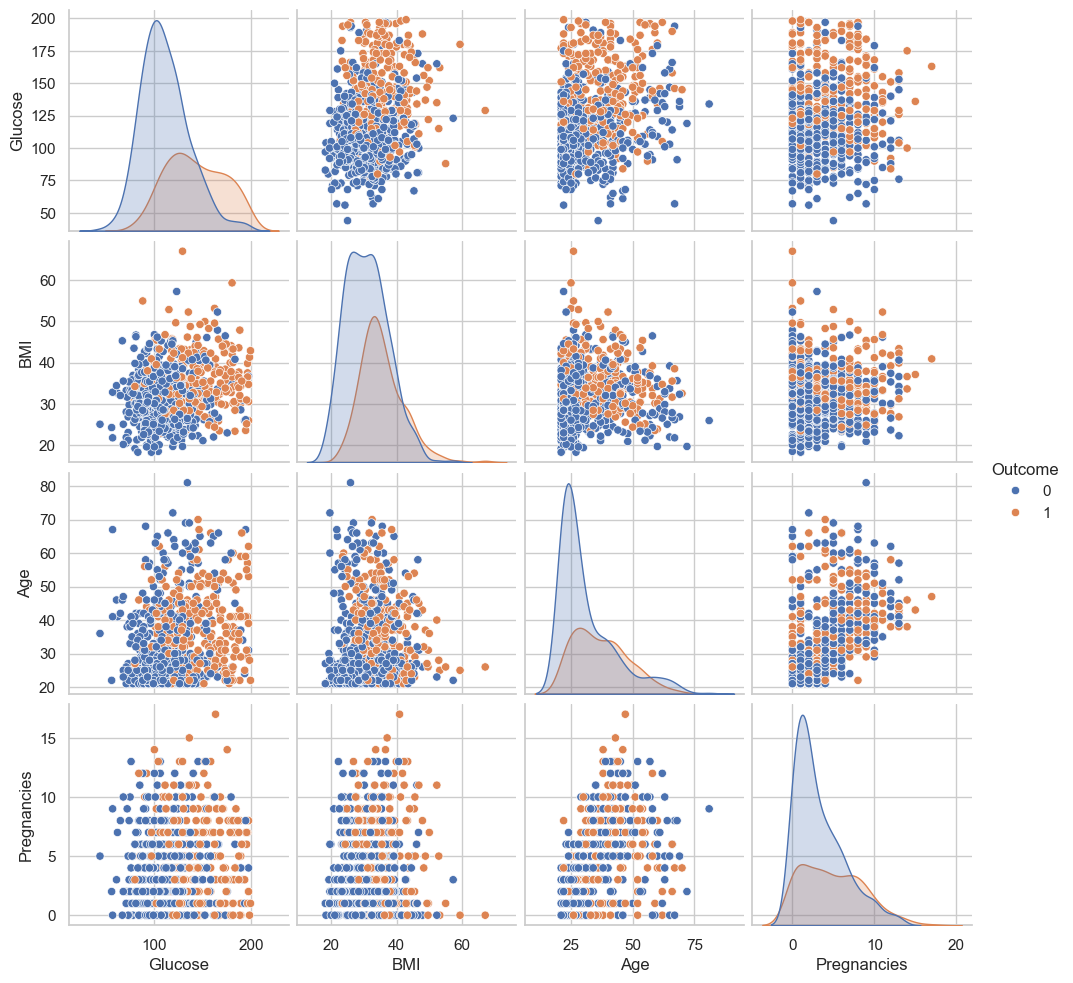

In [16]:
sns.pairplot(diabetes_df, hue='Outcome', diag_kind='kde',
             vars=['Glucose', 'BMI', 'Age', 'Pregnancies'])
plt.show()


No pair of features shows a clean visual split between classes -- the diabetic and
non-diabetic points are heavily intermixed across every 2D combination. This confirms there's
no simple two-feature rule that separates the classes; a model needs to combine signal across
all features, which is exactly what both Logistic Regression and KNN do.


## 6. Preprocessing for Modeling

**Split:** stratified Train / Validation / Test (roughly 56% / 14% / 30%), preserving the
Outcome class ratio in every set. The validation set is used for threshold selection and
sanity-checking; the test set is touched only once, at the very end, for the final unbiased
comparison.

**Scaling:** `StandardScaler` is fit on the training set only, then applied (`.transform()`)
to validation and test -- never re-fit on them, to avoid leaking information from the held-out
sets into the scaling parameters. Scaling matters more for KNN (distance-based) than for
Logistic Regression, but both benefit from it.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = diabetes_df.drop(columns=['Outcome'])
y = diabetes_df['Outcome']

# First split: separate out the test set (70% train+val, 30% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: divide the remaining 70% into train and validation (80/20 of that 70%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")


Train: 429 rows
Validation: 108 rows
Test: 231 rows


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)    # transform only -- never fit on val/test
X_test_scaled = scaler.transform(X_test)  # transform only


## 7. Model 1: Logistic Regression

**Tuning approach:** `GridSearchCV` (rather than `LogisticRegressionCV`) to keep the
methodology consistent with the KNN comparison below, since KNN needs GridSearchCV regardless.
`scoring='recall'` is used throughout, matching the project's priority of minimizing missed
diabetic cases over minimizing false alarms.


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, recall_score, precision_score,
                              roc_curve, roc_auc_score,
                              precision_recall_curve, average_precision_score)

log_model = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],          # solver default (lbfgs) only supports l2; kept
                                 # explicit since L2 also helps stabilize the
                                 # moderately correlated feature pairs found above
    'class_weight': [None, 'balanced'],
}

grid_model = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_model.fit(X_train_scaled, y_train)

print(f"Best params: {grid_model.best_params_}")
print(f"Best Recall score (CV): {grid_model.best_score_:.4f}")

best_log_reg = grid_model.best_estimator_


Best params: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2'}
Best Recall score (CV): 0.7037


### 7.1 Validation Performance — Default Threshold (0.5)

In [20]:
y_val_pred = best_log_reg.predict(X_val_scaled)

print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))


              precision    recall  f1-score   support

           0       0.84      0.76      0.80        70
           1       0.62      0.74      0.67        38

    accuracy                           0.75       108
   macro avg       0.73      0.75      0.74       108
weighted avg       0.76      0.75      0.75       108

[[53 17]
 [10 28]]


### 7.2 Overfitting Check — Train vs. Validation Accuracy

In [21]:
y_train_pred = best_log_reg.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


Train Accuracy: 0.7552
Validation Accuracy: 0.7500


Train and validation accuracy are nearly identical, indicating the model generalizes
well and is not overfitting -- likely a result of the regularization strength (`C`) selected
during tuning.


### 7.3 Threshold Optimization

The default 0.5 cutoff isn't necessarily the best operating point given the project's
recall priority. Predicted probabilities (`predict_proba`) are used instead of hard
predictions, so the classification cutoff can be tuned directly.


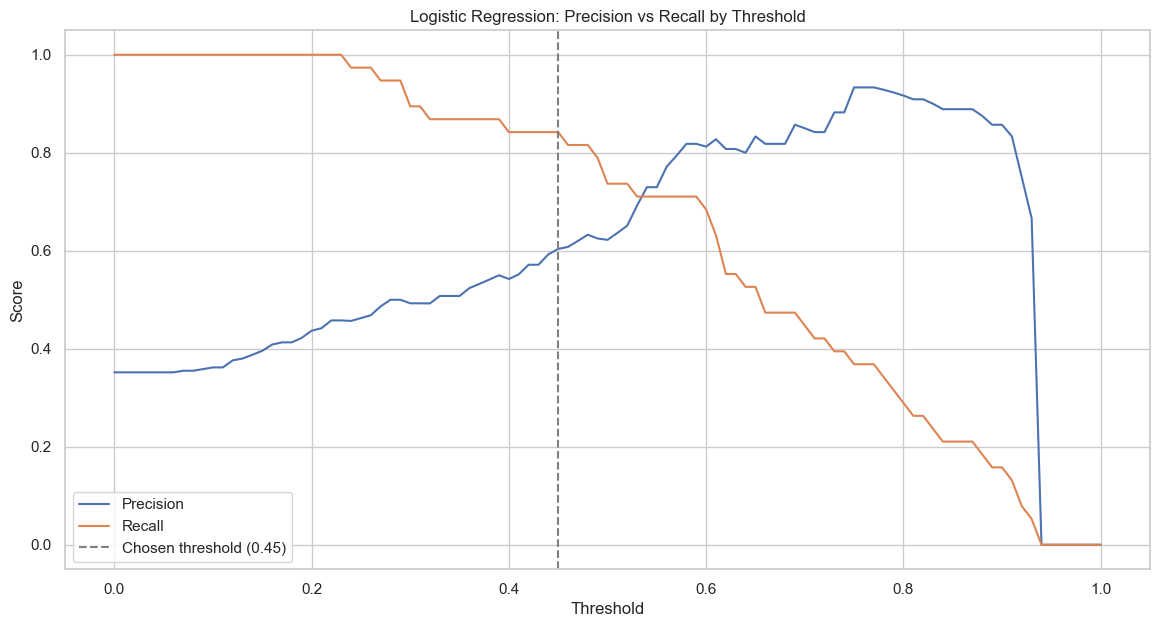

In [40]:
thresholds = np.linspace(0, 1, 101)
y_val_proba = best_log_reg.predict_proba(X_val_scaled)[:, 1]

precision_scores, recall_scores = [], []
for thresh in thresholds:
    y_pred_t = (y_val_proba >= thresh).astype(int)
    precision_scores.append(precision_score(y_val, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_val, y_pred_t, zero_division=0))
plt.figure(figsize=(14,7))
plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.axvline(x=0.45, color='gray', linestyle='--', label='Chosen threshold (0.45)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression: Precision vs Recall by Threshold')
plt.legend()
plt.show()


**Threshold comparison (validation set):**

| Threshold | Recall | Precision | F1 | Accuracy | False Negatives |
|---|---|---|---|---|---|
| 0.50 (default) | 0.74 | 0.62 | 0.67 | 0.75 | 10 |
| **0.45 (chosen)** | **0.84** | 0.60 | **0.70** | 0.75 | **6** |
| 0.35 | 0.87 | 0.51 | 0.64 | 0.66 | 5 |

**0.45 is chosen as the final threshold**: it improves Recall substantially over the default
(74% → 84%, catching 4 more diabetic cases) while keeping Accuracy unchanged and even
improving F1 -- a strictly better operating point than 0.5. Going lower to 0.35 gains only
marginal extra recall at a much steeper cost to Precision and Accuracy.


In [23]:
threshold = 0.45
y_val_pred_adjusted = (y_val_proba >= threshold).astype(int)

print(classification_report(y_val, y_val_pred_adjusted))
print(confusion_matrix(y_val, y_val_pred_adjusted))


              precision    recall  f1-score   support

           0       0.89      0.70      0.78        70
           1       0.60      0.84      0.70        38

    accuracy                           0.75       108
   macro avg       0.75      0.77      0.74       108
weighted avg       0.79      0.75      0.76       108

[[49 21]
 [ 6 32]]


In [24]:
# Confirm the chosen threshold also generalizes well: train vs validation recall
y_train_proba = best_log_reg.predict_proba(X_train_scaled)[:, 1]
y_train_pred_045 = (y_train_proba >= 0.45).astype(int)

train_recall = recall_score(y_train, y_train_pred_045)
val_recall = recall_score(y_val, y_val_pred_adjusted)

print(f"Train Recall (threshold 0.45): {train_recall:.4f}")
print(f"Validation Recall (threshold 0.45): {val_recall:.4f}")


Train Recall (threshold 0.45): 0.7718
Validation Recall (threshold 0.45): 0.8421


### 7.4 Confusion Matrix — Final Threshold (0.45)

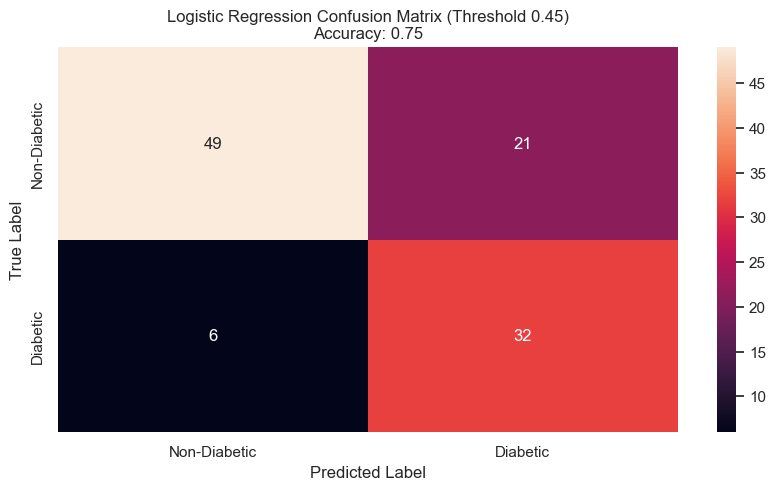

In [37]:
cm = confusion_matrix(y_val, y_val_pred_adjusted)
acc = accuracy_score(y_val, y_val_pred_adjusted)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title(f'Logistic Regression Confusion Matrix (Threshold 0.45)\nAccuracy: {acc:.2f}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### 7.5 ROC and Precision-Recall Curves

These curves summarize model quality *independent* of any single threshold -- AUC and
Average Precision (AP) describe how well the model ranks patients by risk across all possible
cutoffs. The chosen 0.45 threshold is marked on both curves to show exactly where that
specific operating point sits.


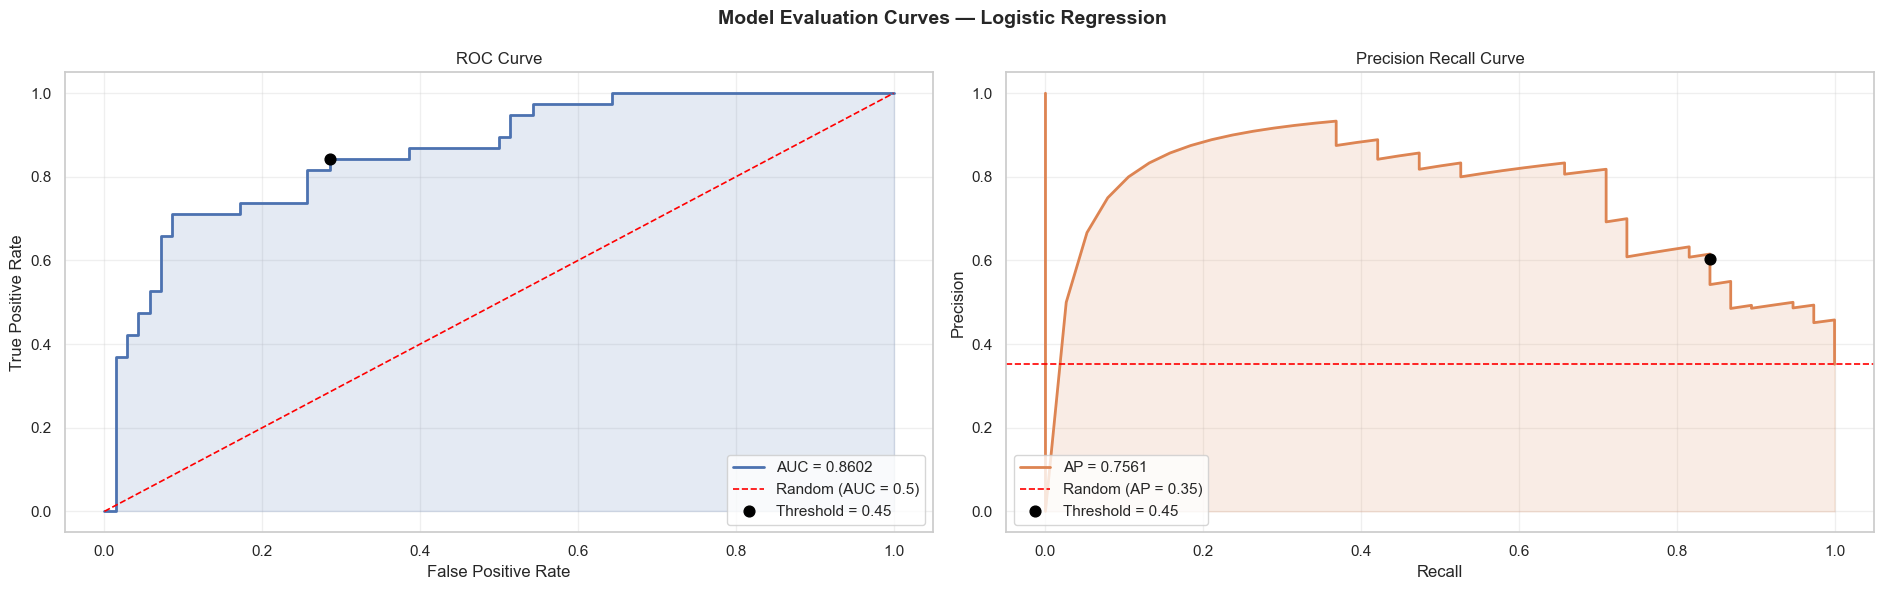

AUC Score:                0.8602
Average Precision Score:  0.7561


In [36]:
y_val_proba = best_log_reg.predict_proba(X_val_scaled)[:, 1]

fpr, tpr, roc_thresh = roc_curve(y_val, y_val_proba)
auc_score = roc_auc_score(y_val, y_val_proba)

precision, recall, pr_thresh = precision_recall_curve(y_val, y_val_proba)
ap_score = average_precision_score(y_val, y_val_proba)
baseline_precision = y_val.mean()

chosen_threshold = 0.45
roc_idx = np.argmin(np.abs(roc_thresh - chosen_threshold))
pr_idx = np.argmin(np.abs(pr_thresh - chosen_threshold))

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
fig.suptitle('Model Evaluation Curves — Logistic Regression', fontsize=14, fontweight='bold')

axes[0].plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'AUC = {auc_score:.4f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1.2, label='Random (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#4C72B0')
axes[0].scatter(fpr[roc_idx], tpr[roc_idx], color='black', zorder=5, s=60, label='Threshold = 0.45')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].plot(recall, precision, color='#DD8452', linewidth=2, label=f'AP = {ap_score:.4f}')
axes[1].axhline(y=baseline_precision, linestyle='--', color='red', linewidth=1.2,
                label=f'Random (AP = {baseline_precision:.2f})')
axes[1].fill_between(recall, precision, alpha=0.15, color='#DD8452')
axes[1].scatter(recall[pr_idx], precision[pr_idx], color='black', zorder=5, s=60, label='Threshold = 0.45')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC Score:                {auc_score:.4f}")
print(f"Average Precision Score:  {ap_score:.4f}")


**Logistic Regression summary:** AUC = 0.86, AP = 0.76, both well above the random
baselines -- strong evidence of genuine discriminative ability. At the chosen 0.45 threshold,
the model catches 84% of diabetic cases on the validation set with accuracy unchanged from
the default cutoff.


## 8. Model 2: K-Nearest Neighbors (KNN)

Same tuning methodology as Logistic Regression (`GridSearchCV`, `scoring='recall'`) for a
fair, apples-to-apples comparison.


In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': list(range(3, 21, 2)),  # odd numbers avoid tie votes in binary classification
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print(f"Best params: {grid_knn.best_params_}")
print(f"Best Recall score (CV): {grid_knn.best_score_:.4f}")

best_knn = grid_knn.best_estimator_


Best params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best Recall score (CV): 0.6234


### 8.1 Validation Performance — Default Threshold (0.5)

In [28]:
y_val_pred_knn = best_knn.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred_knn))
print(confusion_matrix(y_val, y_val_pred_knn))


              precision    recall  f1-score   support

           0       0.77      0.81      0.79        70
           1       0.62      0.55      0.58        38

    accuracy                           0.72       108
   macro avg       0.69      0.68      0.69       108
weighted avg       0.72      0.72      0.72       108

[[57 13]
 [17 21]]


### 8.2 Threshold Optimization

Same process as Logistic Regression: scan the full threshold range on the validation set to
find the best recall-favoring operating point.


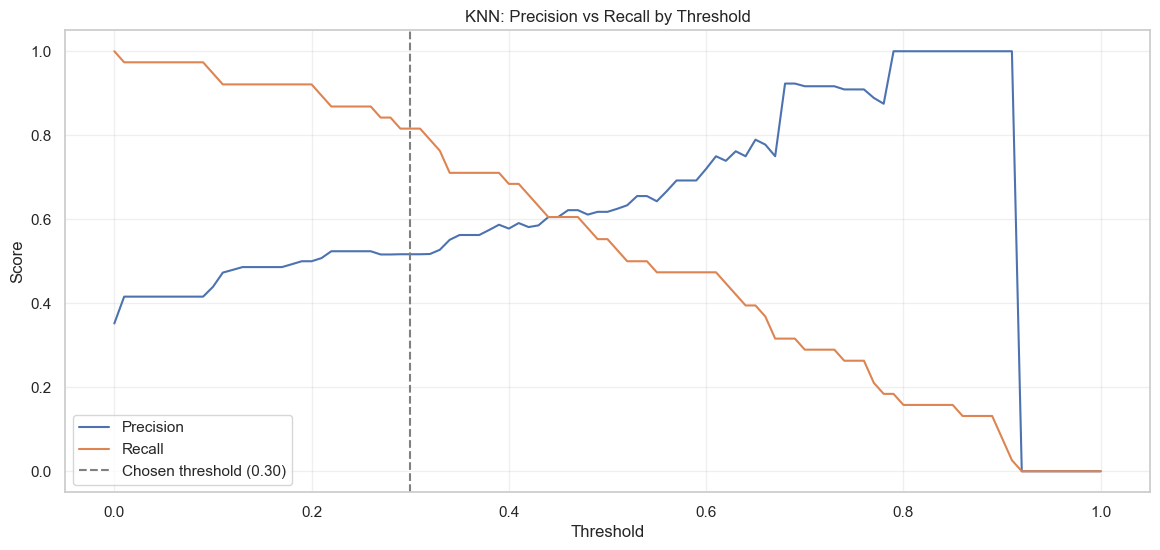

In [41]:
y_val_proba_knn = best_knn.predict_proba(X_val_scaled)[:, 1]

precision_scores_knn, recall_scores_knn = [], []
for t in thresholds:
    y_pred_t = (y_val_proba_knn >= t).astype(int)
    precision_scores_knn.append(precision_score(y_val, y_pred_t, zero_division=0))
    recall_scores_knn.append(recall_score(y_val, y_pred_t, zero_division=0))

plt.figure(figsize=(14, 6))
plt.plot(thresholds, precision_scores_knn, color='#4C72B0', label='Precision')
plt.plot(thresholds, recall_scores_knn, color='#DD8452', label='Recall')
plt.axvline(x=0.30, color='gray', linestyle='--', label='Chosen threshold (0.30)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('KNN: Precision vs Recall by Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Threshold comparison (validation set):**

| Threshold | Recall | Precision | F1 | Accuracy | FN |
|---|---|---|---|---|---|
| 0.50 (default) | 0.55 | 0.62 | 0.58 | 0.72 | 17 |
| 0.45 | 0.61 | 0.61 | 0.61 | 0.72 | 15 |
| 0.35 | 0.71 | 0.56 | 0.63 | 0.70 | 11 |
| **0.30 (chosen)** | **0.82** | 0.52 | 0.63 | 0.67 | **7** |

Going from 0.35 to 0.30 pushes Recall up substantially (0.71 -> 0.82, cutting false negatives
from 11 to 7) while F1 stays essentially flat -- meaning this move trades Precision for
Recall without hurting overall balance. Since the project's stated priority is minimizing
missed diabetic cases (the costly error) over minimizing false alarms (the cheap one),
**0.30** is chosen as KNN's final threshold -- it brings KNN's recall much closer to Logistic
Regression's chosen recall (0.84), making for a fairer final comparison.


In [30]:
threshold_knn = 0.30
y_val_pred_knn_adj = (y_val_proba_knn >= threshold_knn).astype(int)
print(classification_report(y_val, y_val_pred_knn_adj))
print(confusion_matrix(y_val, y_val_pred_knn_adj))


              precision    recall  f1-score   support

           0       0.85      0.59      0.69        70
           1       0.52      0.82      0.63        38

    accuracy                           0.67       108
   macro avg       0.69      0.70      0.66       108
weighted avg       0.74      0.67      0.67       108

[[41 29]
 [ 7 31]]


### 8.3 ROC and Precision-Recall Curves

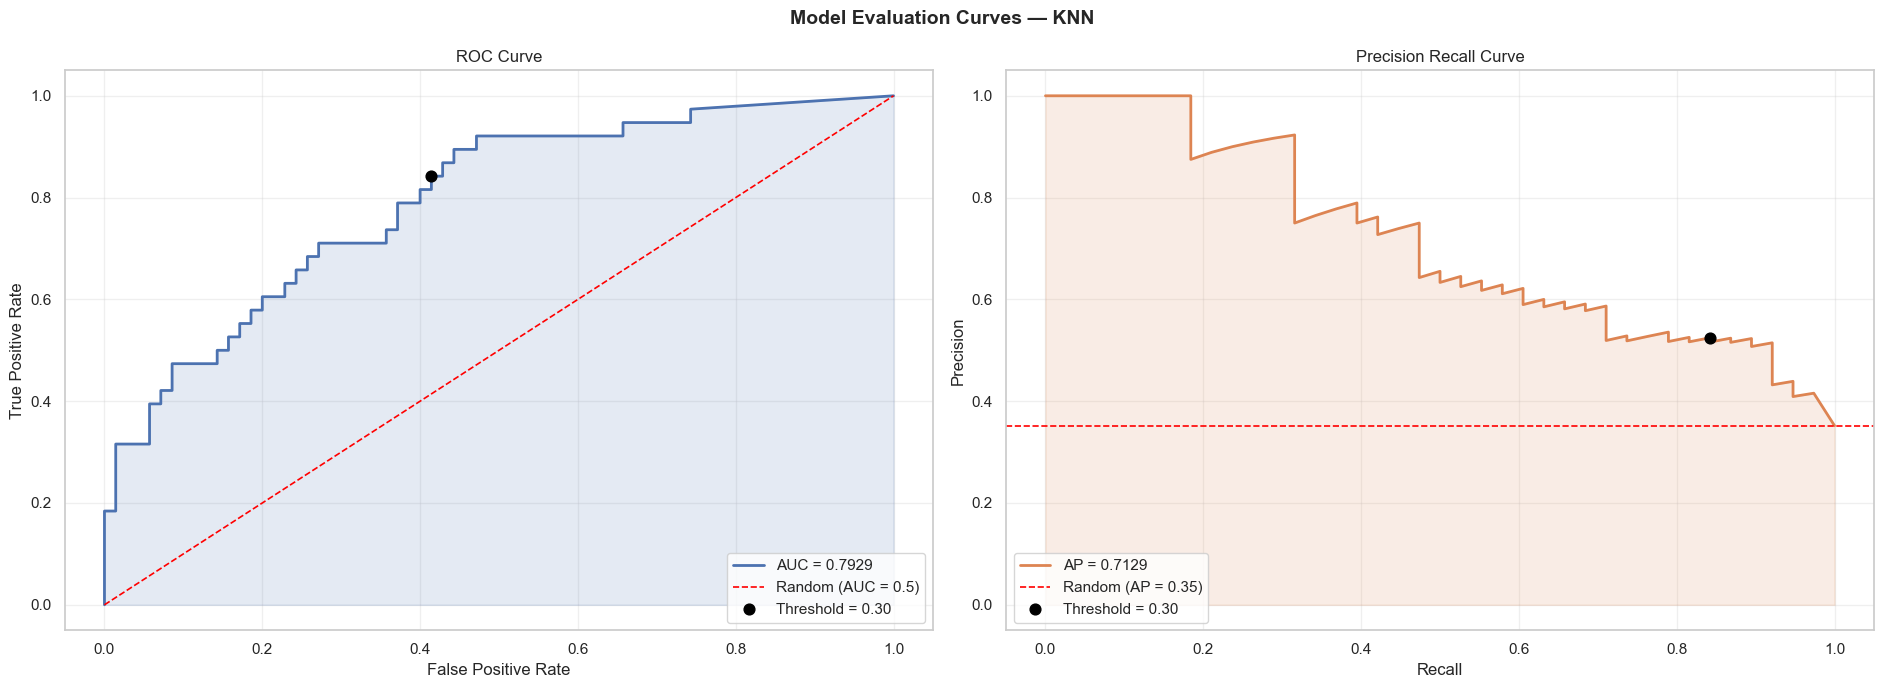

AUC Score:                0.7929
Average Precision Score:  0.7129


In [33]:
fpr_knn, tpr_knn, roc_thresh_knn = roc_curve(y_val, y_val_proba_knn)
auc_knn = roc_auc_score(y_val, y_val_proba_knn)

precision_knn, recall_knn, pr_thresh_knn = precision_recall_curve(y_val, y_val_proba_knn)
ap_knn = average_precision_score(y_val, y_val_proba_knn)

chosen_threshold_knn = 0.30
roc_idx_knn = np.argmin(np.abs(roc_thresh_knn - chosen_threshold_knn))
pr_idx_knn = np.argmin(np.abs(pr_thresh_knn - chosen_threshold_knn))

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
fig.suptitle('Model Evaluation Curves — KNN', fontsize=14, fontweight='bold')

axes[0].plot(fpr_knn, tpr_knn, color='#4C72B0', linewidth=2, label=f'AUC = {auc_knn:.4f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1.2, label='Random (AUC = 0.5)')
axes[0].fill_between(fpr_knn, tpr_knn, alpha=0.15, color='#4C72B0')
axes[0].scatter(fpr_knn[roc_idx_knn], tpr_knn[roc_idx_knn], color='black', zorder=5, s=60,
                 label='Threshold = 0.30')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].plot(recall_knn, precision_knn, color='#DD8452', linewidth=2, label=f'AP = {ap_knn:.4f}')
axes[1].axhline(y=baseline_precision, linestyle='--', color='red', linewidth=1.2,
                label=f'Random (AP = {baseline_precision:.2f})')
axes[1].fill_between(recall_knn, precision_knn, alpha=0.15, color='#DD8452')
axes[1].scatter(recall_knn[pr_idx_knn], precision_knn[pr_idx_knn], color='black', zorder=5, s=60,
                 label='Threshold = 0.30')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC Score:                {auc_knn:.4f}")
print(f"Average Precision Score:  {ap_knn:.4f}")


**KNN summary:** AUC = 0.79, AP = 0.71 (both threshold-independent, unaffected by the
0.30 vs 0.35 choice) -- comfortably better than random, but lower than Logistic Regression on
every metric. Likely explanations: the pairplot showed heavy class overlap in feature space
(KNN relies on locally class-pure neighborhoods), the imputed Insulin/SkinThickness values add
some synthetic noise that distance calculations are more sensitive to, and KNN has no
equivalent to Logistic Regression's regularization for handling the moderately correlated
feature pairs. At the chosen 0.30 threshold, KNN's validation Recall (0.82) closes much of the
gap with Logistic Regression's 0.84 -- worth checking whether that holds on the test set below.


## 9. Final Model Comparison — Held-Out Test Set

This is the first and only evaluation on the test set. Both models are evaluated at their
final chosen thresholds (Logistic Regression: 0.45, KNN: **0.30**), decided entirely from
validation-set analysis above -- the test set was not used in any tuning or threshold
decision.

> **Note:** KNN's threshold was updated from an earlier 0.35 to 0.30 after re-examining the
> validation Precision/Recall tradeoff (0.30 gave a much better Recall for a flat F1 cost --
> see Section 8.2). Since this changes KNN's predictions, the cell below needs to be re-run to
> get this run's actual test-set numbers before filling in the comparison table further down.


In [32]:
# Logistic Regression on test set (threshold 0.45)
y_test_proba_lr = best_log_reg.predict_proba(X_test_scaled)[:, 1]
y_test_pred_lr = (y_test_proba_lr >= 0.45).astype(int)

print("=== Logistic Regression (Test Set, threshold 0.45) ===")
print(classification_report(y_test, y_test_pred_lr))
print(confusion_matrix(y_test, y_test_pred_lr))
print(f"AUC: {roc_auc_score(y_test, y_test_proba_lr):.4f}")
print(f"AP: {average_precision_score(y_test, y_test_proba_lr):.4f}")

print("\n" + "=" * 50 + "\n")

# KNN on test set (threshold 0.30)
y_test_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]
y_test_pred_knn = (y_test_proba_knn >= 0.30).astype(int)

print("=== KNN (Test Set, threshold 0.30) ===")
print(classification_report(y_test, y_test_pred_knn))
print(confusion_matrix(y_test, y_test_pred_knn))
print(f"AUC: {roc_auc_score(y_test, y_test_proba_knn):.4f}")
print(f"AP: {average_precision_score(y_test, y_test_proba_knn):.4f}")


=== Logistic Regression (Test Set, threshold 0.45) ===
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       150
           1       0.59      0.78      0.67        81

    accuracy                           0.74       231
   macro avg       0.73      0.75      0.73       231
weighted avg       0.76      0.74      0.74       231

[[107  43]
 [ 18  63]]
AUC: 0.8374
AP: 0.7170


=== KNN (Test Set, threshold 0.30) ===
              precision    recall  f1-score   support

           0       0.87      0.69      0.77       150
           1       0.59      0.81      0.68        81

    accuracy                           0.74       231
   macro avg       0.73      0.75      0.73       231
weighted avg       0.77      0.74      0.74       231

[[104  46]
 [ 15  66]]
AUC: 0.8263
AP: 0.6936


## 10. Conclusion

| Metric | Logistic Regression (0.45) | KNN (0.30) |
|---|---|---|
| Recall (Diabetes) | 0.78 | **0.81** |
| Precision (Diabetes) | 0.59 | 0.59 |
| F1 (Diabetes) | 0.67 | **0.68** |
| Accuracy | 0.74 | 0.74 |
| AUC | **0.8374** | 0.8263 |
| AP | **0.7170** | 0.6936 |
| False Negatives (missed cases) | 18 | **15** |

**This result is closer -- and more nuanced -- than it first appeared.** Once KNN's threshold
was moved to 0.30, it actually **overtakes** Logistic Regression on the metric this project
cares about most: Recall (0.81 vs. 0.78, missing 15 diabetic cases instead of 18), and edges
ahead on F1 too. Precision and Accuracy are tied. Logistic Regression still holds the edge on
AUC and AP -- the threshold-independent measures of overall ranking quality -- meaning its
underlying probability estimates are somewhat better calibrated across the full range of
thresholds, even though KNN's chosen *operating point* ends up catching slightly more real
cases in practice.

**Practical takeaway:** which model is "better" depends on what's being optimized for. If the
priority is the single number that matters most here -- Recall at the chosen threshold -- KNN
narrowly wins. If the priority is a model with stronger, more reliable probability estimates
in general (useful if the threshold might need to shift later, or if predicted probabilities
themselves are reported to a clinician) -- Logistic Regression is the safer choice. Given how
close the two models are here, either is a defensible final choice; Logistic Regression is
still slightly favored for this project given its stronger AUC/AP and simpler, more
interpretable coefficients, but KNN's threshold-tuned Recall is a legitimate counter-argument
worth stating explicitly in the write-up rather than glossed over.

**On the multicollinearity finding:** the correlations between BMI/SkinThickness and
Glucose/Insulin reflect genuine physiological relationships rather than data redundancy, and
the VIF check confirmed they don't meaningfully compromise either model.

**Limitations worth noting:**
- Small dataset (768 rows total, ~429 for training) limits how much signal any model can learn, especially for the minority (diabetic) class
- SkinThickness and Insulin required substantial imputation; while physiologically-informed and randomized to avoid distribution artifacts, a meaningful portion of those two columns is synthetic rather than measured
- The dataset lacks some clinically important diabetes predictors (e.g. HbA1c, fasting glucose test results), which likely caps how separable the two classes can ever be with this feature set
